# Análise de Medalhas Olímpicas

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df_completo = pd.read_csv('dados-historicos/world_olympedia_olympics_athlete_event_result.csv', low_memory=False)
df_medalhistas = df_completo.dropna(subset=['medal']).copy()

df_2024 = pd.read_csv('dados-paris-2024/medals_total.csv')
df_2024_formatado = df_2024[['country_code', 'country', 'Gold Medal', 'Silver Medal', 'Bronze Medal', 'Total']].copy()
df_2024_formatado.columns = ['Sigla', 'Pais', 'Ouro', 'Prata', 'Bronze', 'Total']

def processar_tabela_historica(df_subset):
    unique_medals = df_subset[['edition', 'country_noc', 'sport', 'event', 'medal']].drop_duplicates()
    
    medal_counts = unique_medals.groupby(['country_noc', 'medal']).size().unstack(fill_value=0)
    
    for col in ['Gold', 'Silver', 'Bronze']:
        if col not in medal_counts.columns:
            medal_counts[col] = 0
            
    medal_counts['Total'] = medal_counts['Gold'] + medal_counts['Silver'] + medal_counts['Bronze']
    
    medal_counts = medal_counts.rename(columns={'Gold': 'Ouro', 'Silver': 'Prata', 'Bronze': 'Bronze'})
    medal_counts = medal_counts.reset_index().rename(columns={'country_noc': 'Sigla'})
    medal_counts['Pais'] = medal_counts['Sigla']
    
    return medal_counts[['Sigla', 'Pais', 'Ouro', 'Prata', 'Bronze', 'Total']]

def juntar_com_2024(tabela_hist, tabela_2024):
    concat_df = pd.concat([tabela_hist, tabela_2024], ignore_index=True)
    
    agrupado = concat_df.groupby('Sigla').agg({
        'Pais': 'first',
        'Ouro': 'sum',
        'Prata': 'sum',
        'Bronze': 'sum',
        'Total': 'sum'
    }).reset_index()
    
    paises_2024 = dict(zip(tabela_2024['Sigla'], tabela_2024['Pais']))
    agrupado['Pais'] = agrupado['Sigla'].map(lambda s: paises_2024.get(s, s))
    
    agrupado = agrupado.sort_values(
        ['Ouro', 'Prata', 'Bronze', 'Total', 'Pais'], 
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)
    agrupado.insert(0, 'Posicao', range(1, len(agrupado) + 1))
    
    return agrupado

def criar_tabela_sem_2024(tabela_hist):
    agrupado = tabela_hist.sort_values(
        ['Ouro', 'Prata', 'Bronze', 'Total', 'Pais'], 
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)
    agrupado.insert(0, 'Posicao', range(1, len(agrupado) + 1))
    return agrupado

def plotar_top50(tabela, titulo):
    top50 = tabela.head(50).copy().iloc[::-1]
    top50['Rotulo'] = top50['Sigla'] + ' - ' + top50['Pais']
    ax = top50.plot(
        x='Rotulo',
        y=['Bronze', 'Prata', 'Ouro'],
        kind='barh',
        stacked=True,
        figsize=(12, 16),
        color=['#cd7f32', '#c0c0c0', '#d4af37'],
        width=0.85,
    )
    ax.set_title(titulo)
    ax.set_xlabel('Medalhas')
    ax.set_ylabel('')
    ax.legend(title='')
    plt.tight_layout()
    plt.show()

is_winter = df_medalhistas['edition'].str.contains('Winter', case=False, na=False)
tabela_historica_inverno = processar_tabela_historica(df_medalhistas[is_winter])
tabela_historica_verao = processar_tabela_historica(df_medalhistas[~is_winter])
tabela_historica_geral = processar_tabela_historica(df_medalhistas)

tabela_verao = juntar_com_2024(tabela_historica_verao, df_2024_formatado)
tabela_geral = juntar_com_2024(tabela_historica_geral, df_2024_formatado)
tabela_inverno = criar_tabela_sem_2024(tabela_historica_inverno)


## Medalhas - Jogos de Verão

In [3]:
display(tabela_verao)

,Posicao,Sigla,Pais,Ouro,Prata,Bronze,Total
0,1,USA,United States,1106,884,784,2774
1,2,URS,URS,394,317,294,1005
2,3,GBR,Great Britain,307,345,343,995
3,4,CHN,China,303,226,197,726
4,5,GER,Germany,252,280,298,830
5,6,FRA,France,245,281,303,829
6,7,ITA,Italy,234,208,230,672
7,8,JPN,Japan,189,161,190,540
8,9,HUN,Hungary,188,163,182,533
9,10,AUS,Australia,180,189,226,595


## Medalhas - Jogos de Inverno

In [4]:
display(tabela_inverno)

medal,Posicao,Sigla,Pais,Ouro,Prata,Bronze,Total
0,1,NOR,NOR,147,134,123,404
1,2,USA,USA,113,119,95,327
2,3,GER,GER,112,104,70,286
3,4,CAN,CAN,77,72,76,225
4,5,URS,URS,77,56,59,192
5,6,AUT,AUT,71,88,91,250
6,7,SWE,SWE,65,51,60,176
7,8,SUI,SUI,63,47,57,167
8,9,NED,NED,53,49,45,147
9,10,RUS,RUS,46,39,35,120


## Medalhas - Total Geral

In [5]:
display(tabela_geral)

,Posicao,Sigla,Pais,Ouro,Prata,Bronze,Total
0,1,USA,United States,1219,1003,879,3101
1,2,URS,URS,471,373,353,1197
2,3,GER,Germany,364,384,368,1116
3,4,CHN,China,325,258,220,803
4,5,GBR,Great Britain,320,350,360,1030
5,6,FRA,France,286,323,358,967
6,7,ITA,Italy,276,251,286,813
7,8,SWE,Sweden,219,231,244,694
8,9,NOR,Norway,207,188,176,571
9,10,JPN,Japan,206,189,221,616


## Gráfico - Top 50 Jogos de Verão

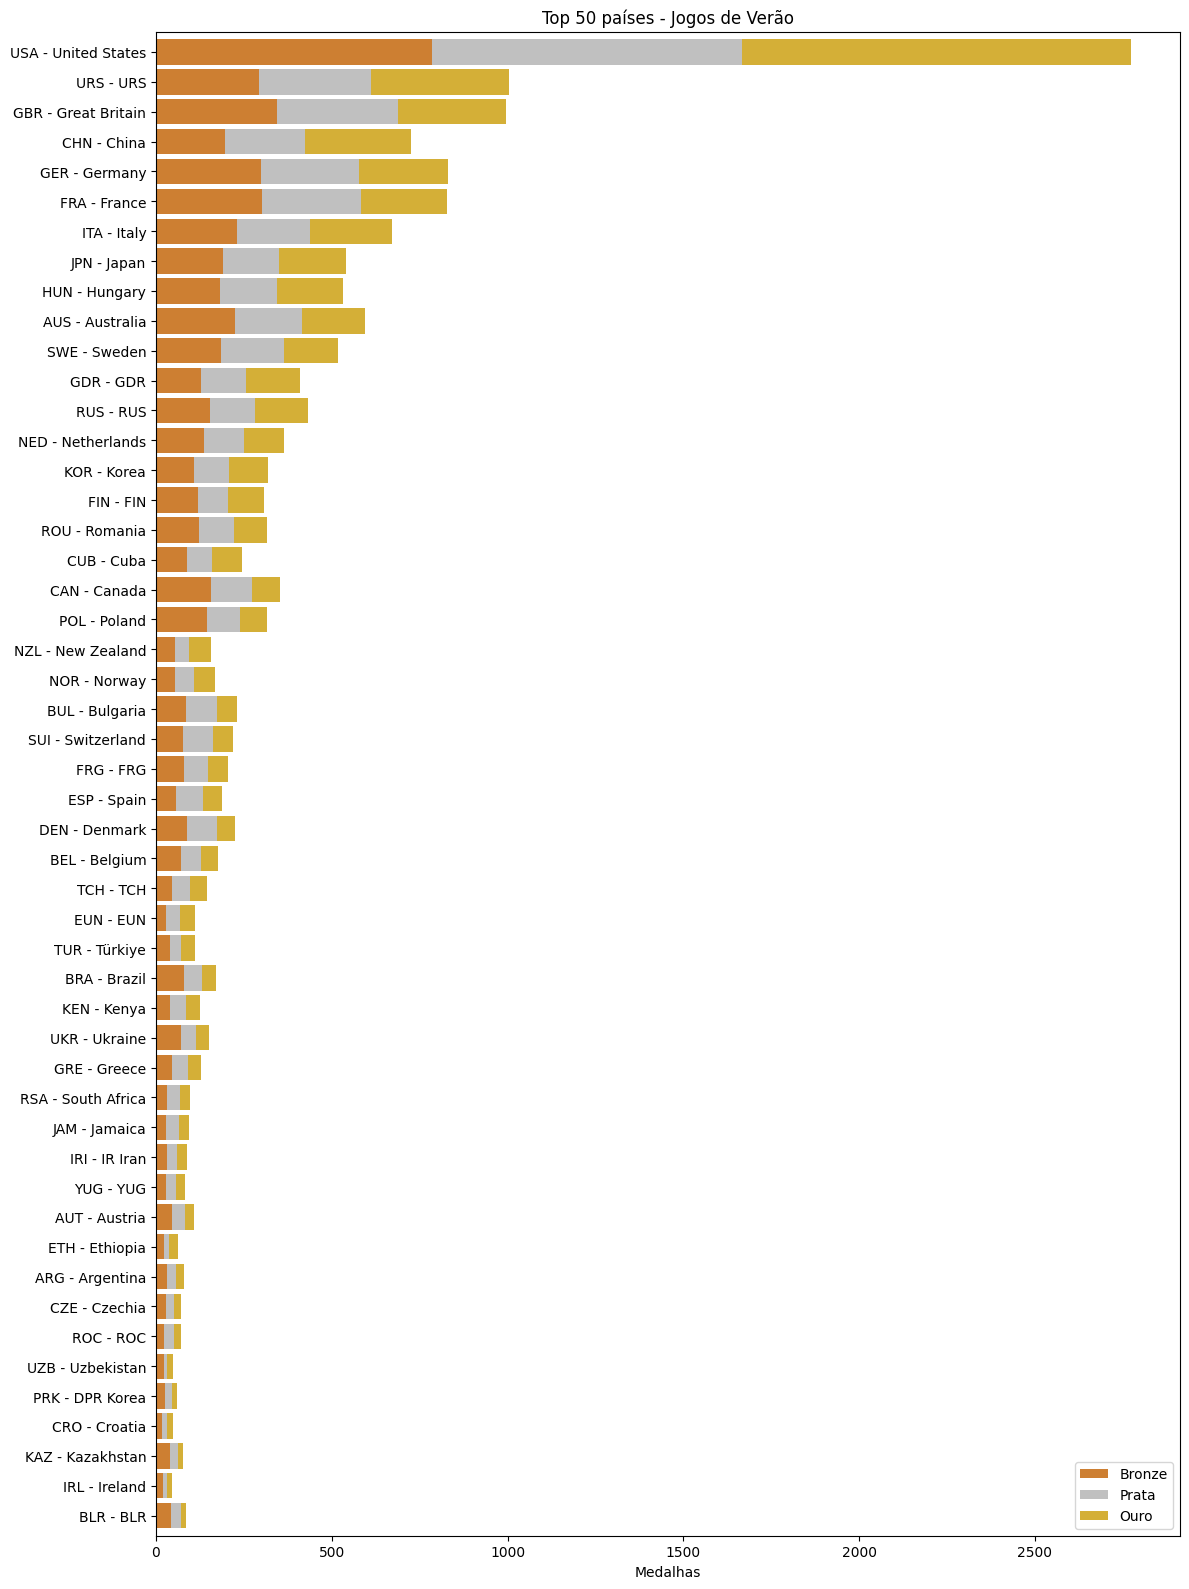

In [6]:
plotar_top50(tabela_verao, 'Top 50 países - Jogos de Verão')

## Gráfico - Top 50 Jogos de Inverno

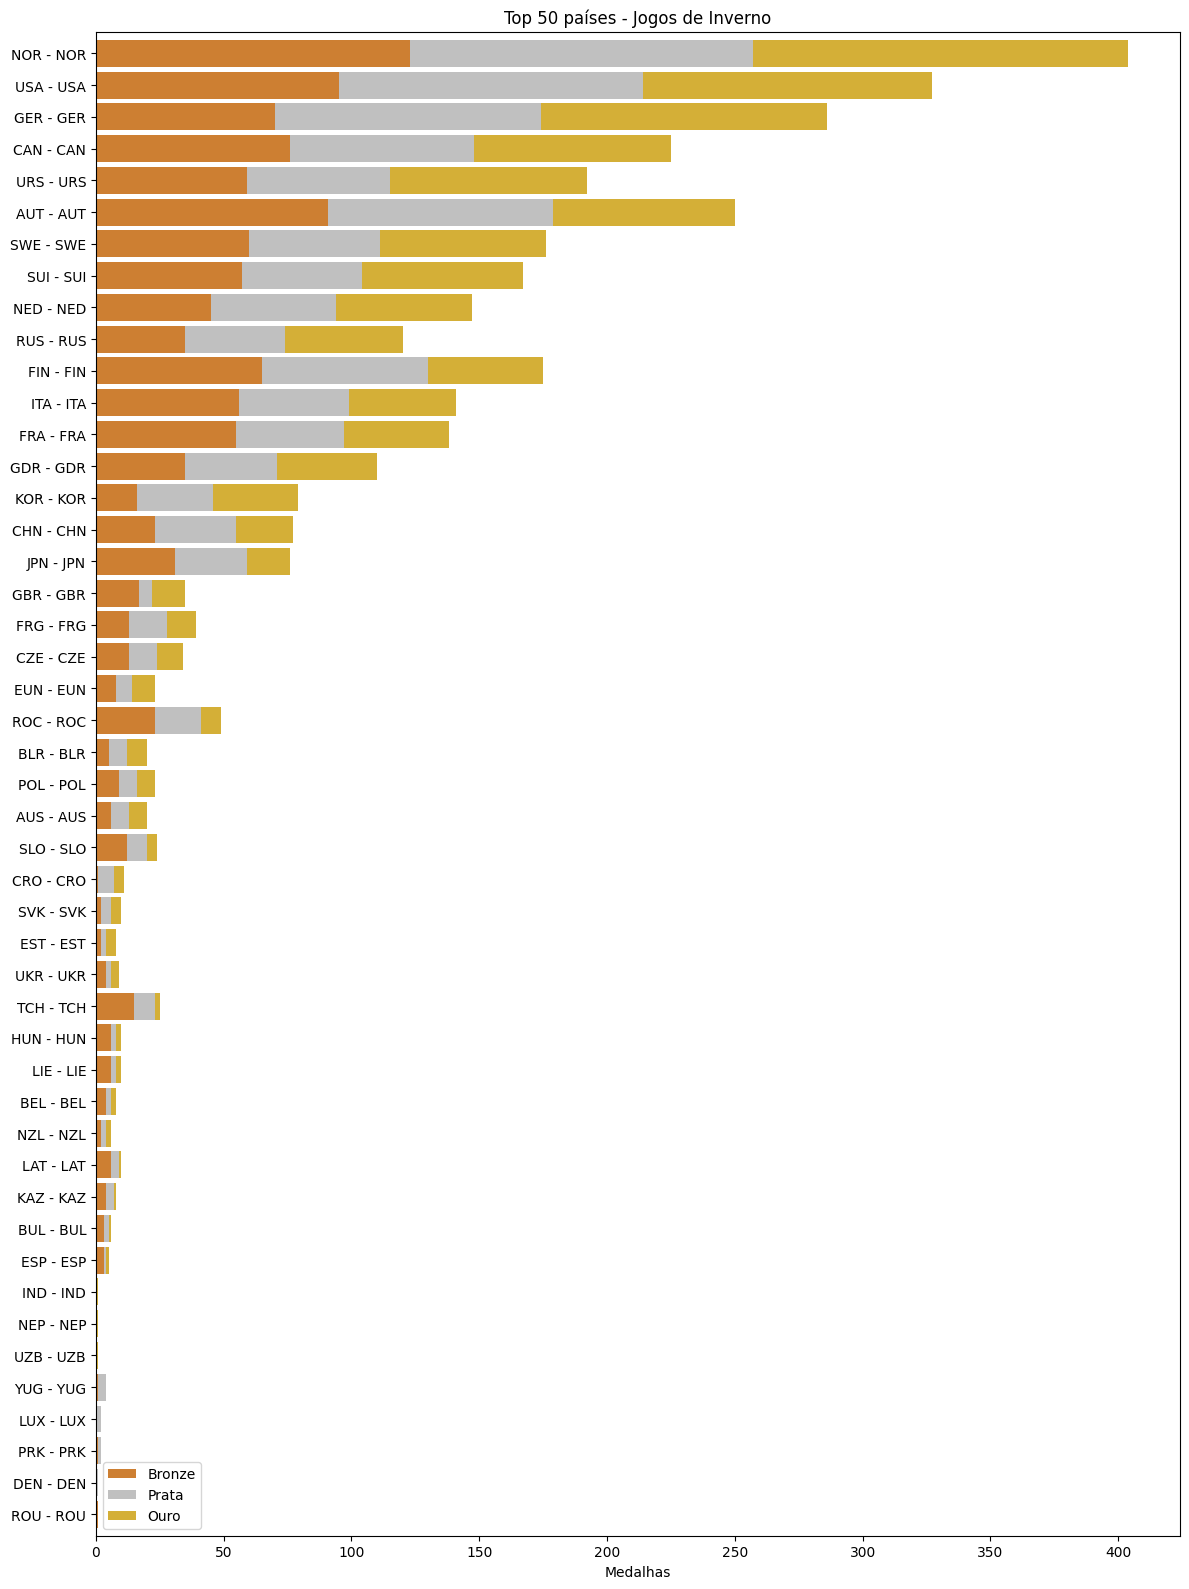

In [7]:
plotar_top50(tabela_inverno, 'Top 50 países - Jogos de Inverno')

## Gráfico - Top 50 Total Geral

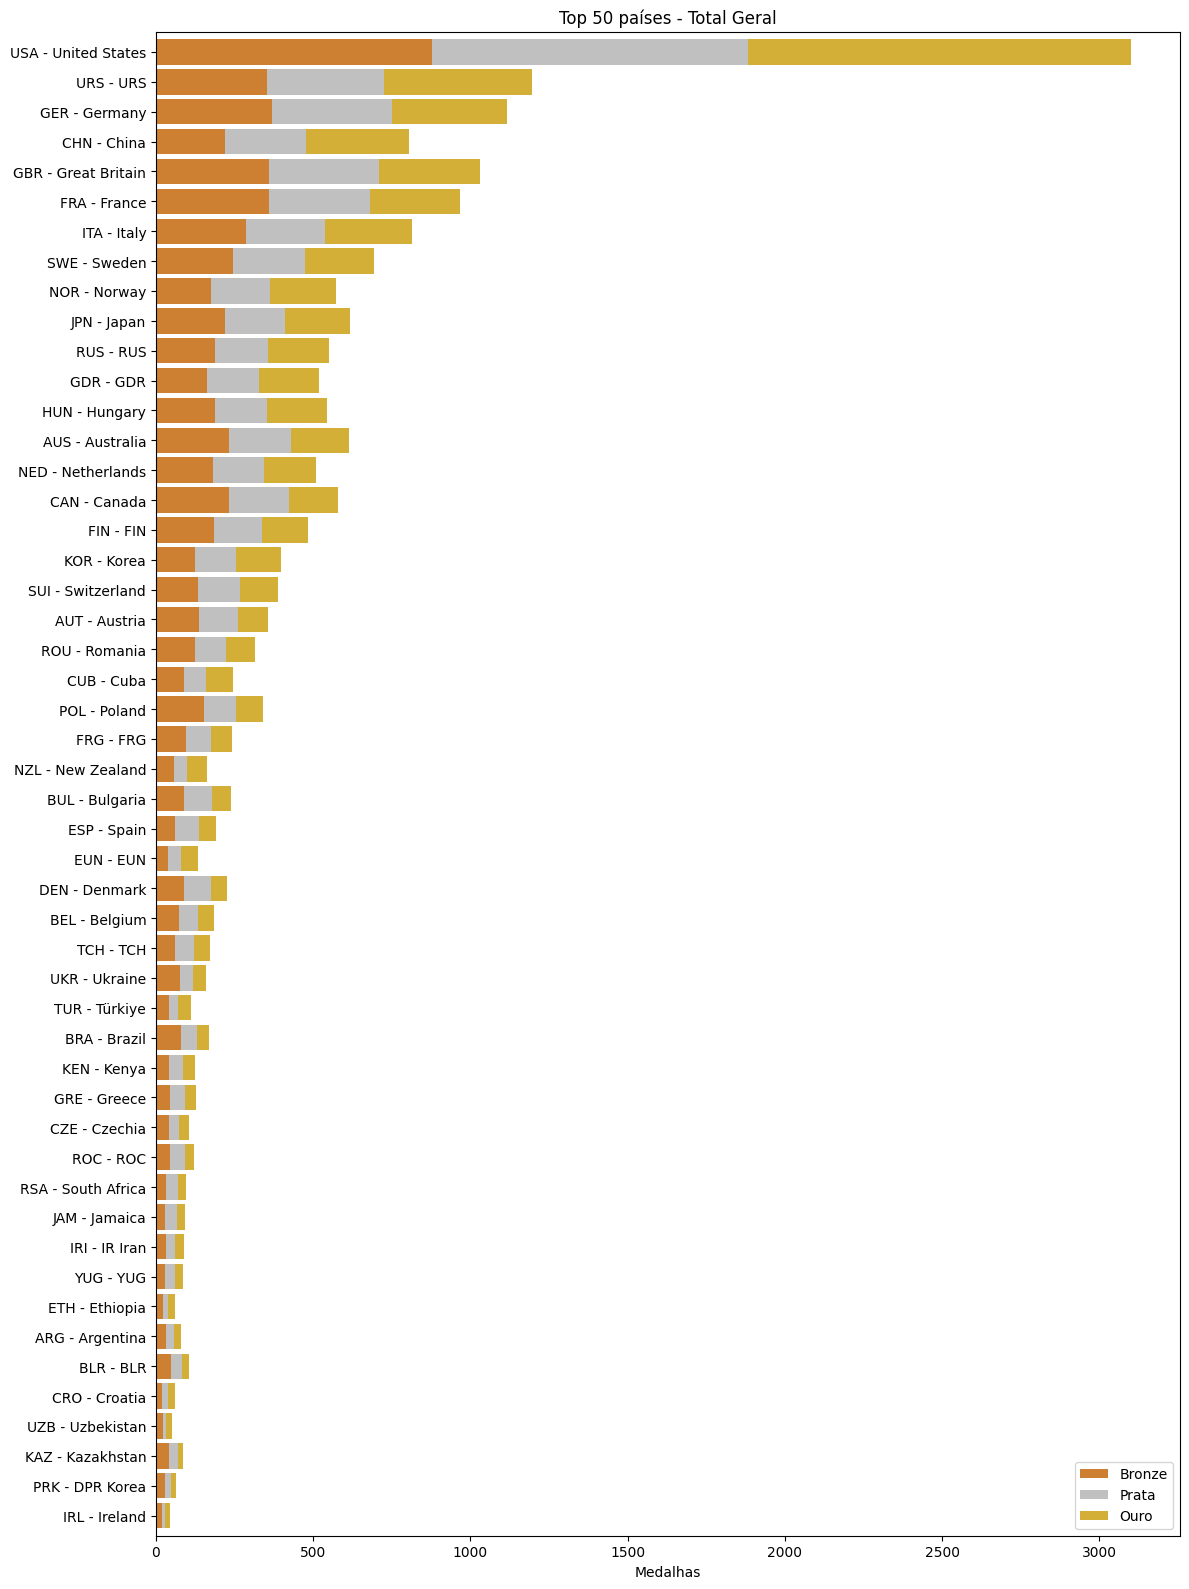

In [8]:
plotar_top50(tabela_geral, 'Top 50 países - Total Geral')